# Notebook 2 - Handwritten digits

## 0. Importing modules and downloading Dataset

In [4]:
import time
import urllib
import scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram

from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

Instantiate the variables with the dataset name and the paths.

In [5]:
url  = "https://github.com/amplab/datascience-sp14/raw/master/lab7/mldata/mnist-original.mat"
path = "../data/mnist-original.mat"

Download and load the dataset.

In [6]:
# Download the .mat file
urllib.request.urlretrieve(url, path)

('../data/mnist-original.mat', <http.client.HTTPMessage at 0x7d6a18dcee40>)

In [7]:
mnist = scipy.io.loadmat(path)
mnist_data  = mnist["data"].T
mnist_label = mnist["label"][0]

In [8]:
print("Number of datapoints: {}\n".format(mnist_data.shape[0]))
print("Number of features: {}\n".format(mnist_data.shape[1]))
print("List of labels: {}\n".format(np.unique(mnist_label)))

Number of datapoints: 70000

Number of features: 784

List of labels: [0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]



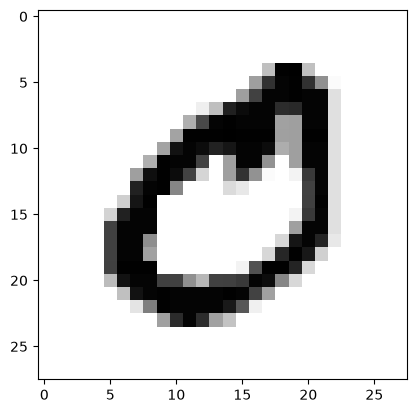

In [9]:
index = 1
image = mnist_data[index].reshape(28, 28)

plt.imshow(image, cmap=plt.cm.gray_r)
plt.show()

## 1. Preparing data 

In [10]:
# Scale the data to be either a 1 or a 0
scaled_data = mnist_data/255.0

data_train, data_test, labels_train, labels_test = train_test_split(mnist_data, mnist_label, test_size=0.2)

## 2. Training models and collecting data

In [11]:
results_df = pd.DataFrame(columns=["Model Name", "Accuracy", "Precision", "Recall", "F1 Score", "Training Time (s)"])

In [12]:
def print_and_add(model_name, labels_test, results, training_time, results_df):

    accuracy = accuracy_score(labels_test, results)
    precision = precision_score(labels_test, results, average='weighted')
    recall = recall_score(labels_test, results, average='weighted')
    f1 = f1_score(labels_test, results, average='weighted')

    print(f"  Accuracy:       {accuracy:.4f}")
    print(f"  Precision:      {precision:.4f}")
    print(f"  Recall:         {recall:.4f}")
    print(f"  F1 Score:       {f1:.4f}")

    row = {
        "Model Name":        model_name,
        "Accuracy":          round(accuracy, 4),
        "Precision":         round(precision, 4),
        "Recall":            round(recall, 4),
        "F1 Score":          round(f1, 4),
        "Training Time (s)": round(training_time, 4)
    }

    return pd.concat([results_df, pd.DataFrame([row])], ignore_index=True)

In [13]:
# Create a kmeans model with 10 clusters
kmeans = KMeans(n_clusters=10)
kmeans.fit(scaled_data)

start = time.time()
results = kmeans.predict(data_test)    
training_time = time.time() - start

results_df = print_and_add("KMeans", labels_test, results, training_time, results_df)

  Accuracy:       0.0431
  Precision:      0.0223
  Recall:         0.0431
  F1 Score:       0.0287


Loop through the 10 clusters.

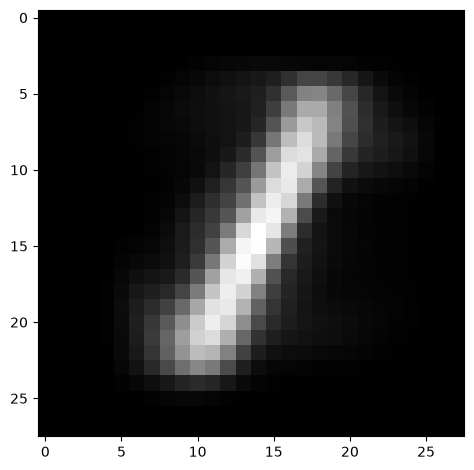

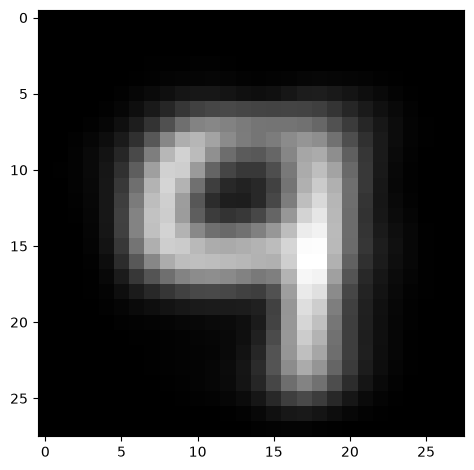

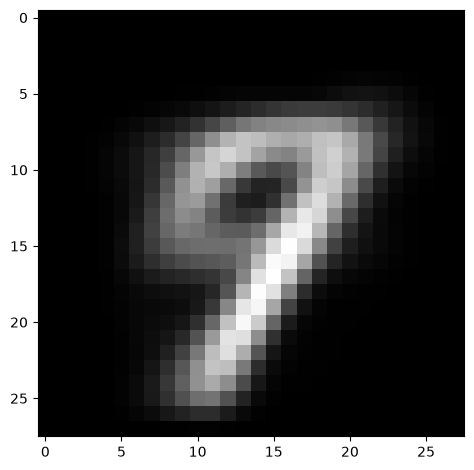

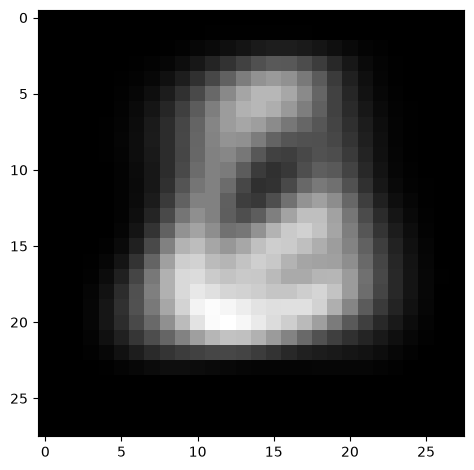

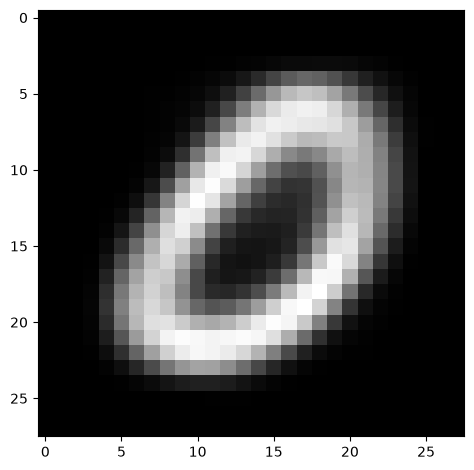

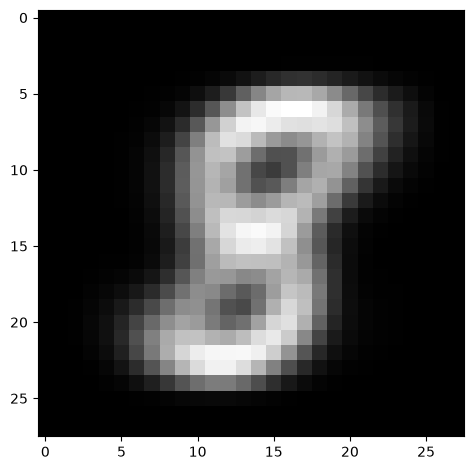

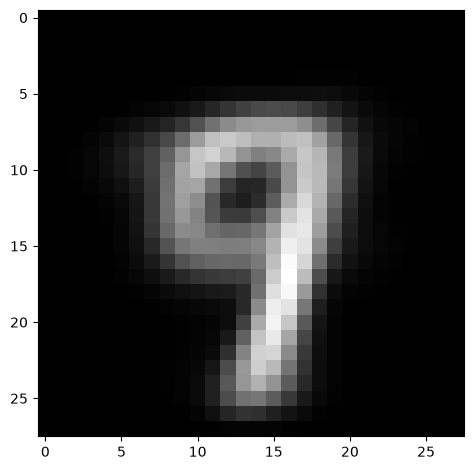

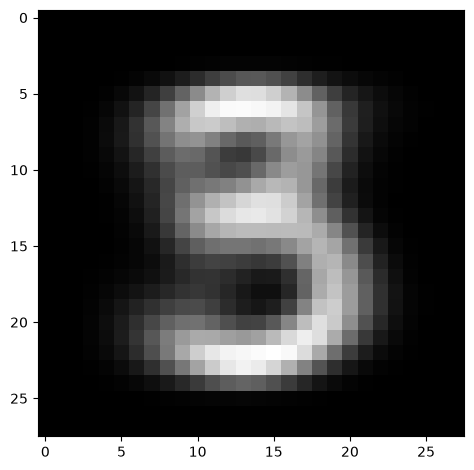

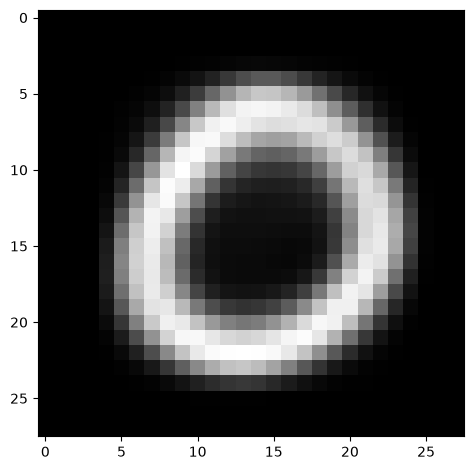

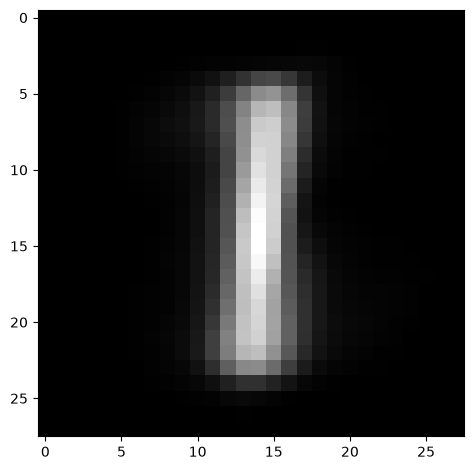

In [14]:
for i in range(10):
  center = kmeans.cluster_centers_[i]

  image = center.reshape(28, 28)

  plt.imshow(image, cmap=plt.cm.gray)
  plt.tight_layout()
  plt.show()

Perform a supervised clustering evaluation using adjusted rand index, this is used to see if the results stable across random restarts of k-means.

In [15]:
small_mnist_data, small_mnist_label = resample(mnist_data, mnist_label, n_samples=500, replace=False)

scaler = StandardScaler()
scaler.fit(small_mnist_data)
X_scaled = scaler.transform(small_mnist_data)

kmeans = KMeans(n_clusters=10)

# Perform 10 random restarts of kmeans and calculate the ARI for each
for i in range(10):
  labels = kmeans.fit_predict(X_scaled)

  # This allows us to determine whether the results of the clustering 
  # are stable when performing multiple random restarts of k-means.
  ari = adjusted_rand_score(labels, small_mnist_label)
  print("ARI of random restarts: {:.2f}".format(ari))

ARI of random restarts: 0.29
ARI of random restarts: 0.33
ARI of random restarts: 0.26
ARI of random restarts: 0.33
ARI of random restarts: 0.26
ARI of random restarts: 0.27
ARI of random restarts: 0.29
ARI of random restarts: 0.29
ARI of random restarts: 0.31
ARI of random restarts: 0.28


Now we perform hierarchical clustering on the data.

In [16]:
# Define a function to plot a dendrogram
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    dendrogram(linkage_matrix, **kwargs)

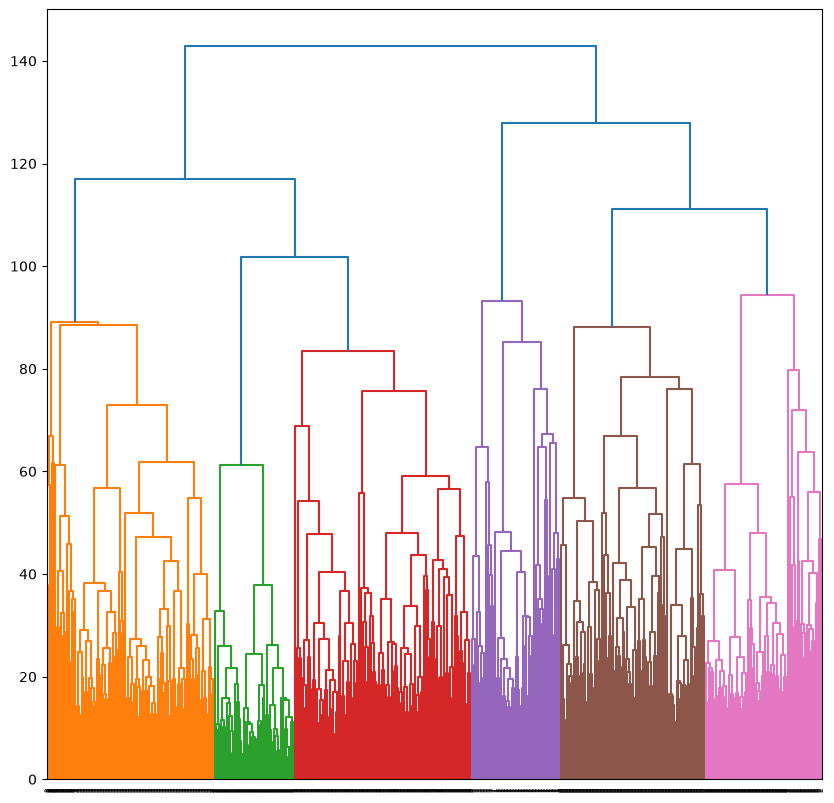

In [17]:
# Resample the data to include 500 samples
small_mnist_data, small_mnist_label = resample(mnist_data, mnist_label, n_samples=500, replace=False, random_state=69)

# Standardize the data
scaler = StandardScaler()
scaler.fit(small_mnist_data)
X_scaled = scaler.transform(small_mnist_data)

# Perform hierarchical clustering with 10 clusters
model = AgglomerativeClustering(n_clusters=10, compute_distances=True)
model.fit(X_scaled)

# Plot the dendrogram
plt.figure(figsize=(10, 10))
plot_dendrogram(model, labels=model.labels_)
plt.show()

## 3. Training a neural network

In [21]:
def train(net, train_values, train_labels, test_values, test_labels, num_epochs):
    x_train = torch.FloatTensor(train_values)
    x_test  = torch.FloatTensor(test_values)
    y_train = torch.LongTensor(train_labels)
    y_test  = torch.LongTensor(test_labels)

    # Wrap in DataLoader for batching
    train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
    test_loader  = DataLoader(TensorDataset(x_test,  y_test),  batch_size=32)

    # Setup
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)

    # Training loop
    for epoch in range(num_epochs):
        net.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            loss = criterion(net(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        net.eval()
        correct = total = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = net(X_batch).argmax(dim=1)
                correct += (preds == y_batch).sum().item()
                total   += y_batch.size(0)

        print(f"Epoch {epoch+1:>3} | Test acc: {correct/total:.4f}")

In [24]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        self.pool = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=2, kernel_size=(3, 3), stride=(1, 1), padding=1),
            nn.MaxPool2d(3, 3)
        )

        self.fc = nn.Sequential(
            nn.Linear(162, 100),
            nn.ReLU(inplace=True),
            nn.Linear(100, 50),
            nn.ReLU(inplace=True),
            nn.Linear(50, 10)
        )

    def forward(self, x):
        x = x.view(-1, 1, 28, 28)
        x = self.pool(x)
        x = x.view(-1, 162)
        x = self.fc(x)
        return x

In [25]:
net = Net()
net = train(net, data_train, labels_train, data_test, labels_test, 2)

Epoch   1 | Test acc: 0.8911
Epoch   2 | Test acc: 0.9314
